# NSF FMRG Data Challenge 2026 Submission Notebook:  
**Team** : Sakshi Sowmya Aravind, Sravya Pogiri, Udaya Raja (Rutgers University)

**Predicting Local Laser-Track Width from Thermal Imaging Submission Notebook**
###**Pipeline:**
1. Load thermal and height data
2. Extract track width and boundaries from the missing vs measured pixels (profilometer validity pattern)
3. Build thermal features
4. Compare 8 models under Cross-track validation with 1 track being left out
5. Verify the negative result
6. Calibrate uncertainty
7. Detect anomalies
8. Produce Track 21 submission.

To run the full analysis, use **Runtime** and select **Run all**. All outputs and submission files will automatically save to /content/nsf_fmrg/outputs/

## 0. Setup - download data, imports, configuration, helper functions

---

Pulls the challenge data straight from Zenodo into the Colab session. This was done so that the notebook runs on its own without needing anything from Google Drive. It loads the libraries, sets constants used throughout (laser powers, pixel sizes, the melt threshold), and defines loader functions that read the thermal .mat files and the Wyko .asc height maps.

In [ ]:
# Download the challenge data from Zenodo into the Colab runtime
import zipfile, urllib.request
from pathlib import Path

RAW = Path('/content/nsf_fmrg/data/raw')
RAW.mkdir(parents=True, exist_ok=True)

DATA = {
    'thermal':     'https://zenodo.org/records/21285367/files/thermal.zip?download=1',
    'height_maps': 'https://zenodo.org/records/21285367/files/height_maps.zip?download=1',
}
for name, url in DATA.items():
    dest = RAW / name
    if dest.exists() and any(p.is_file() for p in dest.rglob('*')):
        print(name, '- already present, skipping download')
        continue
    dest.mkdir(parents=True, exist_ok=True)
    print(name, '- downloading...')
    zpath = f'/content/{name}.zip'
    urllib.request.urlretrieve(url, zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(dest)
    print(name, '- done')
print('\nData ready under', RAW)

thermal - downloading...
thermal - done
height_maps - downloading...
height_maps - done

Data ready under /content/nsf_fmrg/data/raw


In [ ]:
# Imports and configuration
import re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.io import loadmat

PROJECT_DIR = Path('/content/nsf_fmrg')
RAW_DIR     = PROJECT_DIR / 'data' / 'raw'
THERMAL_DIR = RAW_DIR / 'thermal'
HEIGHT_DIR  = RAW_DIR / 'height_maps'
OUT_DIR     = PROJECT_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRACK_IDS = [8, 10, 14, 21]
POWER_W   = {8: 400, 10: 350, 14: 300, 21: 200}      # Tracks are mapped to their Power Level
HELD_OUT_SUBMISSION = 21                               # lowest power/coolest track -> held out for extrapolation

COMMON_X_START_MM, COMMON_X_END_MM = 20.0, 100.0
THERMAL_FPS, SCAN_SPEED_MM_PER_S = 50.0, 10.0
THERMAL_MM_PER_FRAME = SCAN_SPEED_MM_PER_S / THERMAL_FPS            # 0.2 mm / frame
EXTRACTED_THERMAL_FRAMES = int(round((COMMON_X_END_MM - COMMON_X_START_MM) / THERMAL_MM_PER_FRAME))
THERMAL_PIXEL_SIZE_MM = 0.014
MELT_THRESHOLD = 1500.0        # raw counts, above this = molten
WARM_LO = 800.0                # lower bound for the cooling tail behind the melt pool

# extraction / feature parameters
DENSITY_THRESH = 0.60          # validity-density cutoff for the track band
SMOOTH_Y, SMOOTH_X = 5, 25     # smoothing window (rows, cols) for validity mask
MIN_BAND_ROWS = 25             # drop bands thinner than ~0.1mm
GOOD_X_MIN, GOOD_X_MAX = 25.0, 97.0   # scan line ends are unstable -> low confidence
ROLL_W = 51                    # 25 back + 1 + 25 fwd = 51 frames for rolling stats like stability and drift.
BIN_CENTERS = np.round(np.arange(20.1, 100.0, 0.2), 1)    # 0.2mm grid, matches thermal frames

print('Config loaded. Expected extracted frames per track:', EXTRACTED_THERMAL_FRAMES)

Config loaded. Expected extracted frames per track: 400


In [ ]:
# Helper functions: thermal (.mat) and Wyko (.asc) loaders
def natural_key(s):
    s = str(s)
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]

def find_track_file(root, track_id, suffixes):
    root = Path(root)
    suffixes = {s.lower() for s in suffixes}
    matches = []
    if not root.exists():
        return None
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in suffixes:
            name = p.name.lower()
            if re.search(rf'(^|[_\-\s]){track_id}($|[_\-\s\.])', name) or f'{track_id}' in name:
                matches.append(p)
    matches = sorted(matches, key=natural_key)
    return matches[0] if matches else None

def _loadmat_any(path):
    path = Path(path)
    try:
        data = loadmat(path)
        return {k: v for k, v in data.items() if not k.startswith('__')}
    except NotImplementedError:
        import h5py
        out = {}
        with h5py.File(path, 'r') as f:
            def visit(name, obj):
                if hasattr(obj, 'shape'):
                    try:
                        out[name] = np.array(obj)
                    except Exception:
                        pass
            f.visititems(visit)
        return out

def find_thermal_array(mat_dict):
    candidates = []
    for k, v in mat_dict.items():
        arr = np.squeeze(np.asarray(v))
        if arr.ndim not in (3, 4) or not np.issubdtype(arr.dtype, np.number):
            continue
        if arr.ndim == 4:
            small = [i for i, d in enumerate(arr.shape) if d in (1, 3, 4)]
            if small:
                arr = np.squeeze(np.take(arr, indices=0, axis=small[-1]))
        if arr.ndim != 3:
            continue
        candidates.append((arr.size * (10 if 400 in arr.shape else 1), k, arr))
    if not candidates:
        raise ValueError('No thermal-like array found in MAT file.')
    candidates.sort(key=lambda x: x[0], reverse=True)
    key, arr = candidates[0][1], candidates[0][2]
    s = arr.shape
    if s[0] == s[1] and s[2] != s[0]:
        arr_t = np.moveaxis(arr, 2, 0)
    elif s[1] == s[2]:
        arr_t = arr
    else:
        arr_t = np.moveaxis(arr, int(np.argmax(s)), 0)
    return np.asarray(arr_t, dtype=np.float32), key

def thermal_frame_score(frames, top_percentile=99.5):
    return np.array([np.nanpercentile(fr, top_percentile) for fr in frames], dtype=np.float64)

def largest_true_run(mask):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return None, None
    idx = np.flatnonzero(mask)
    breaks = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[breaks + 1]]
    stops = np.r_[idx[breaks] + 1, idx[-1] + 1]
    j = int(np.argmax(stops - starts))
    return int(starts[j]), int(stops[j])

def detect_laser_on_interval(frames):
    score = thermal_frame_score(frames)
    n = len(score)
    pre = score[:max(5, n // 10)]
    med = np.nanmedian(pre)
    mad = 1.4826 * np.nanmedian(np.abs(pre - med))
    range_thr = np.nanmin(score) + 0.20 * (np.nanmax(score) - np.nanmin(score))
    threshold = max(range_thr, med + 8.0 * max(mad, 1e-12))
    on_start, on_stop = largest_true_run(score > threshold)
    if on_start is None:
        raise ValueError("Could not detect laser-on interval.")
    return on_start, on_stop, score, threshold

def extract_final_thermal_frames(track_id):
    path = find_track_file(THERMAL_DIR, track_id, ['.mat'])
    if path is None:
        raise FileNotFoundError(f"No MAT file for track {track_id} in {THERMAL_DIR}")
    frames, key = find_thermal_array(_loadmat_any(path))
    on_start, on_stop, score, threshold = detect_laser_on_interval(frames)
    stop_idx = int(on_stop)
    start_idx = max(0, stop_idx - EXTRACTED_THERMAL_FRAMES)
    segment = frames[start_idx:stop_idx]
    indices = np.arange(start_idx, stop_idx)
    x_mm_center = COMMON_X_END_MM - ((stop_idx - indices) - 0.5) * THERMAL_MM_PER_FRAME
    return {'file': str(path), 'raw_frames': frames, 'frames': segment,
            'x_mm_center': x_mm_center, 'score': score, 'threshold': float(threshold),
            'on_start': int(on_start), 'on_stop': int(on_stop),
            'start_idx': int(start_idx), 'stop_idx': int(stop_idx)}

def parse_wyko_header(path):
    header = {}
    with open(path, 'r', errors='replace') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[0].lower() == 'x' and parts[1].lower() == 'size':
                header['x_size'] = int(float(parts[2]))
            elif len(parts) >= 3 and parts[0].lower() == 'y' and parts[1].lower() == 'size':
                header['y_size'] = int(float(parts[2]))
            elif parts and parts[0].lower() == 'pixel_size':
                header['pixel_size_mm'] = float(parts[-1])
            if parts and parts[0].upper() == 'RAW_DATA':
                break
    return header

def load_wyko_asc(track_id, crop_to_common=True):
    path = find_track_file(HEIGHT_DIR, track_id, ['.asc', '.txt'])
    if path is None:
        raise FileNotFoundError(f"No ASC/TXT file for track {track_id} in {HEIGHT_DIR}")
    header = parse_wyko_header(path)
    x_size, y_size = int(header['x_size']), int(header['y_size'])
    pixel = float(header.get('pixel_size_mm', 0.003982))
    n_expected = x_size * y_size
    z = np.full(n_expected, np.nan, dtype=np.float32)
    count, in_raw = 0, False
    with open(path, 'r', errors='replace') as f:
        for line in f:
            parts = line.strip().split()
            if not in_raw:
                if parts and parts[0].upper() == 'RAW_DATA':
                    in_raw = True
                continue
            if len(parts) < 3:
                continue
            tok = parts[2]
            z[count] = np.nan if tok.lower() == 'bad' else float(tok) * 1e-6
            count += 1
            if count >= n_expected:
                break
    if count < n_expected:
        warnings.warn(f"Read {count} rows, expected {n_expected}.")
    Z_yx = z.reshape((x_size, y_size)).T
    x_local = np.arange(x_size, dtype=np.float64) * pixel
    y_mm = np.arange(y_size, dtype=np.float64) * pixel
    x_actual_raw = 100.0 - x_local           # raw local x=0 is the 100 mm side
    order = np.argsort(x_actual_raw)
    x_actual, Z_yx = x_actual_raw[order], Z_yx[:, order]
    if crop_to_common:
        m = (x_actual >= COMMON_X_START_MM) & (x_actual <= COMMON_X_END_MM)
        x_actual, Z_yx = x_actual[m], Z_yx[:, m]
    return {'Z_mm': Z_yx, 'x_actual_mm': x_actual, 'y_mm': y_mm, 'header': header, 'file': str(path)}

def robust_plane_detrend(Z_mm, x_mm, y_mm, stride_x=40, stride_y=2):
    Zs, xs, ys = Z_mm[::stride_y, ::stride_x], x_mm[::stride_x], y_mm[::stride_y]
    Xs, Ys = np.meshgrid(xs, ys)
    zf = Zs.ravel()
    A = np.c_[Xs.ravel(), Ys.ravel(), np.ones(Xs.size)]
    valid = np.isfinite(zf)
    if valid.sum() < 100:
        return Z_mm.copy(), None
    keep, coef = valid.copy(), None
    for _ in range(3):
        coef, *_ = np.linalg.lstsq(A[keep], zf[keep], rcond=None)
        resid = zf - A @ coef
        lo, hi = np.nanpercentile(resid[valid], [5, 95])
        kn = valid & (resid >= lo) & (resid <= hi)
        if kn.sum() < 100:
            break
        keep = kn
    plane = coef[0] * x_mm[None, :] + coef[1] * y_mm[:, None] + coef[2]
    return Z_mm - plane, coef

print("Helper functions defined.")

Helper functions defined.


## 1. Track geometry from the profilometer width, boundaries, roughness

---

The height maps don't include a width column, and 37-55% of pixels are missing, so we measure width ourselves. We found that the melted track is smooth and gets read cleanly, while the rough metal around it comes back blank. That means the pattern of measured pixels, which contains the density of valid measurements, outlines the track. We use that to figure out the width, the two edges, and the roughness at every position, and we check how much the width shifts if we change our cutoff.

In [ ]:
# Width, boundaries, roughness per 0.2 mm bin; + threshold sensitivity
def geometry_for_track(tid, dens_thresh=DENSITY_THRESH):
    data = load_wyko_asc(tid, crop_to_common=True)
    Z, x, y = data['Z_mm'], data['x_actual_mm'], data['y_mm']
    pixel_mm = float(y[1] - y[0])
    Z_detr, _ = robust_plane_detrend(Z, x, y)
    Z_um = Z_detr * 1000.0
    dens = ndimage.uniform_filter(np.isfinite(Z).astype(np.float32), size=(SMOOTH_Y, SMOOTH_X))

    n = len(x)
    width = np.full(n, np.nan); yu = np.full(n, np.nan); yl = np.full(n, np.nan)
    rough = np.full(n, np.nan); level = np.full(n, np.nan)
    for j in range(n):
        s, e = largest_true_run(dens[:, j] >= dens_thresh)
        if s is not None and (e - s) >= MIN_BAND_ROWS:
            width[j] = (e - s) * pixel_mm
            yu[j], yl[j] = y[s], y[e - 1]
            col = Z_um[s:e, j]
            if np.isfinite(col).sum() >= 10:
                rough[j] = np.nanstd(col)
                level[j] = np.nanmedian(col)
    return x, width, yu, yl, rough, level, pixel_mm

geom_rows, sens_rows, geom_summary = [], [], {}
for tid in TRACK_IDS:
    x, width, yu, yl, rough, level, pix = geometry_for_track(tid)
    idx = np.clip(((x - 20.0) / 0.2).astype(int), 0, len(BIN_CENTERS) - 1)
    def binned(v):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            return np.array([np.nanmean(v[idx == b]) for b in range(len(BIN_CENTERS))])
    def binned_std(v):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            return np.array([np.nanstd(v[idx == b]) if np.isfinite(v[idx == b]).sum() > 1 else np.nan
                             for b in range(len(BIN_CENTERS))])
    wm, ws = binned(width), binned_std(width)
    t = pd.DataFrame({
        'track': tid, 'power_W': POWER_W[tid], 'x_mm': BIN_CENTERS,
        'width_mean': wm, 'width_std': ws,
        'y_upper': binned(yu), 'y_lower': binned(yl),
        'rough_um': binned(rough), 'level_um': binned(level),
    })
    t['centerline'] = (t['y_upper'] + t['y_lower']) / 2.0
    t['rough_roll_um'] = t['level_um'].rolling(ROLL_W, center=True, min_periods=8).std()
    t['waviness_um']   = t['level_um'].rolling(ROLL_W, center=True, min_periods=8).mean()
    t['quality_flag']  = np.where((t.x_mm >= GOOD_X_MIN) & (t.x_mm <= GOOD_X_MAX), 'ok', 'low_confidence')
    geom_rows.append(t)

    # threshold-sensitivity: mean width at 0.50 / 0.60 / 0.70
    for th in (0.50, 0.60, 0.70):
        _, w2, *_ = geometry_for_track(tid, dens_thresh=th)
        sens_rows.append({'track': tid, 'threshold': th, 'mean_width_mm': np.nanmean(w2)})
    geom_summary[tid] = {'mean_width_mm': float(np.nanmean(wm))}
    print(f'Track {tid} ({POWER_W[tid]} W): mean width {np.nanmean(wm):.3f} mm')

geom = pd.concat(geom_rows, ignore_index=True)
sens = pd.DataFrame(sens_rows).pivot(index='track', columns='threshold', values='mean_width_mm')
print('\nMean width (mm) vs density threshold  (systematic sensitivity):')
print(sens.round(3))
print('\nMax shift across thresholds: %.3f mm (sensitivity to dens_thresh choice)' %
      float((sens.max(axis=1) - sens.min(axis=1)).max()))

Track 8 (400 W): mean width 0.994 mm
Track 10 (350 W): mean width 0.750 mm
Track 14 (300 W): mean width 0.670 mm
Track 21 (200 W): mean width 0.456 mm

Mean width (mm) vs density threshold  (systematic sensitivity):
threshold    0.5    0.6    0.7
track                         
8          1.023  1.003  0.982
10         0.809  0.760  0.704
14         0.702  0.670  0.633
21         0.486  0.458  0.430

Max shift across thresholds: 0.105 mm (sensitivity to dens_thresh choice)


## 2. Thermal features and the master table

---

This section converts the thermal video into numerical values. For each 0.2 mm slice of the track, we measure 15 characteristics of the melt pool, like size, shape, intensity, thermal stability, drift, and cooling behavior. We then combine these characteristics and align them with the width labels by position to build a single table containing both the inputs and the answer for each slice. The specific variables we consider are:

1. **melt_area** - the physical size (in pixels) of the glowing melt pool when the laser is hitting it.
2. **pool_wid** *(Pool Width)* - The horizontal width of the glowing melt pool is measured relative to the direction the laser is moving.
3. **pool_len** *(Pool length)* - how long the melt pool is measured relative to the direction the laser is moving.
4. **pool_aspect** *(Pool Aspect Ratio)*- the length-to-width ratio (round vs stretched pool).
5. **peak** - the single hottest, brightest reading in the frame for the melt pool.
6. **melt_intensity** - the total heat added up over just the molten pixels.
7. **total_emission** - The combined total heat or light energy given off by the entire melt pool.
8. **warm_tail_area** - the size of the warm (but not molten) trail behind the pool, which hints at how fast it's cooling.
9. **cooling_rate** - how fast the hottest reading changes from one frame to the next.
10. **peak_roll_mean** *(Peak Rolling Mean)*- the average peak over a moving window, which smooths out quick blips to show the general level.
11. **peak_roll_std** *(Peak Rolling Standard Deviation)* - How much the peak temperature flickers or jumps up and down over a moving window.
12. **area_roll_std** *(Area Rolling Standard Deviation)* - how much the pool size wobbles over the window.
13. **spike_count** - how many frames in the window jump far from the local average (sudden bursts).
14. **trend_slope** - whether the peak is slowly rising or falling across the window.
15. **detrended_roll_std** *(Detrended Rolling Standard Deviation)* - The remaining flicker after stripping out the slow rise and fall, keeping drift and jitter separate.

We compute all 15, but the width model uses only the first 10 (the melt-pool size and intensity ones). We found the flicker and drift features (11–15) didn't help predict width and actually made the unseen-power predictions worse, so we left them out of the model.

In [ ]:
# Per-slice thermal features from the .mat videos
def features_for_track(tid):
    r = extract_final_thermal_frames(tid)
    frames, x_thermal = r['frames'], r['x_mm_center']
    n = len(frames); flat = frames.reshape(n, -1)
    melt = frames > MELT_THRESHOLD
    warm = (frames > WARM_LO) & ~melt

    pool_len = np.zeros(n); pool_wid = np.zeros(n); pool_aspect = np.full(n, np.nan)
    for i in range(n):
        if melt[i].any():
            lab, nlab = ndimage.label(melt[i])
            big = np.argmax(ndimage.sum(melt[i], lab, range(1, nlab + 1))) + 1
            ys, xs = np.where(lab == big)
            pool_len[i] = (xs.max() - xs.min() + 1) * THERMAL_PIXEL_SIZE_MM
            pool_wid[i] = (ys.max() - ys.min() + 1) * THERMAL_PIXEL_SIZE_MM
            if pool_wid[i] > 0:
                pool_aspect[i] = pool_len[i] / pool_wid[i]

    d = pd.DataFrame({
        'track': tid, 'x_mm': np.round(x_thermal, 1),
        'melt_area': melt.sum(axis=(1, 2)) * THERMAL_PIXEL_SIZE_MM**2,
        'pool_wid': pool_wid, 'pool_len': pool_len, 'pool_aspect': pool_aspect,
        'peak': np.nanmax(flat, axis=1),
        'melt_intensity': np.where(melt, frames, 0).sum(axis=(1, 2)),
        'total_emission': np.nansum(flat, axis=1),
        'warm_tail_area': warm.sum(axis=(1, 2)) * THERMAL_PIXEL_SIZE_MM**2,
        'cooling_rate': np.gradient(np.nanmax(flat, axis=1)),
    })
    roll = lambda s, fn: s.rolling(ROLL_W, center=True, min_periods=15).apply(fn, raw=True)
    d['peak_roll_mean'] = d['peak'].rolling(ROLL_W, center=True, min_periods=15).mean()
    d['peak_roll_std']  = d['peak'].rolling(ROLL_W, center=True, min_periods=15).std()
    d['area_roll_std']  = d['melt_area'].rolling(ROLL_W, center=True, min_periods=15).std()
    d['spike_count']    = roll(d['peak'], lambda a: float((np.abs(a - a.mean()) > 2*a.std()).sum()) if a.std() else 0.0)
    d['trend_slope']    = roll(d['peak'], lambda a: np.polyfit(np.arange(len(a)), a, 1)[0])
    d['detrended_roll_std'] = roll(d['peak'], lambda a: np.std(a - np.polyval(np.polyfit(np.arange(len(a)), a, 1), np.arange(len(a)))))
    return d, r['raw_frames'].shape[0]

feat_rows, raw_counts = [], {}
for tid in TRACK_IDS:
    d, raw_n = features_for_track(tid)
    feat_rows.append(d); raw_counts[tid] = raw_n
    print(f'Track {tid}: {len(d)} slices, features built (raw frames = {raw_n})')
feat = pd.concat(feat_rows, ignore_index=True)

master = feat.merge(geom.drop(columns=['power_W']), on=['track', 'x_mm'], how='left')
master['power_W'] = master['track'].map(POWER_W)
master.to_csv(OUT_DIR / 'master.csv', index=False)
print('\nmaster table:', master.shape, 'Saved to outputs/master.csv')
master.head()

Track 8: 400 slices, features built (raw frames = 929)
Track 10: 400 slices, features built (raw frames = 961)
Track 14: 400 slices, features built (raw frames = 976)
Track 21: 400 slices, features built (raw frames = 1012)

master table: (1600, 28) Saved to outputs/master.csv


,track,x_mm,melt_area,pool_wid,pool_len,pool_aspect,peak,melt_intensity,total_emission,warm_tail_area,...,width_std,y_upper,y_lower,rough_um,level_um,centerline,rough_roll_um,waviness_um,quality_flag,power_W
0,8,20.1,0.857108,1.078,1.022,0.948052,2738.0,8963682.0,191786112.0,30.502696,...,NaN,NaN,NaN,NaN,NaN,NaN,10.286325,125.495536,low_confidence,400
1,8,20.3,0.850052,1.064,1.050,0.986842,2727.0,8999822.0,188058624.0,30.509360,...,NaN,NaN,NaN,NaN,NaN,NaN,11.134296,124.331536,low_confidence,400
2,8,20.5,0.835548,1.050,1.022,0.973333,2713.0,8805319.0,191446272.0,30.523864,...,NaN,NaN,NaN,NaN,NaN,NaN,11.900023,123.195399,low_confidence,400
3,8,20.7,0.834372,1.050,1.022,0.973333,2703.0,8745756.0,190681760.0,30.525432,...,NaN,NaN,NaN,NaN,NaN,NaN,12.404069,122.202837,low_confidence,400
4,8,20.9,0.833392,1.050,1.036,0.986667,2683.0,8687970.0,191981968.0,30.526412,...,NaN,NaN,NaN,NaN,NaN,NaN,12.749721,121.319459,low_confidence,400


## 3. Data verification

---

We check our copy of the data against the numbers provided to confirm that the frame counts and the fraction of missing pixels match. This shows us that the download was complete and nothing was corrupted during any of the processes.

In [ ]:
# Frame counts and missing-value fractions vs. provider references
expected_frames  = {8: 929, 10: 961, 14: 976, 21: 1012}
expected_missing = {8: 36.9, 21: 55.5}      # provider-reported (%)

print('Thermal frame counts:')
for tid in TRACK_IDS:
    ok = raw_counts[tid] == expected_frames[tid]
    print(f'  Track {tid}: {raw_counts[tid]} (expected {expected_frames[tid]}) {"OK" if ok else "MISMATCH"}')

print('\nHeight-map missing fraction:')
for tid in TRACK_IDS:
    Z = load_wyko_asc(tid, crop_to_common=True)['Z_mm']
    pct = 100 * np.isnan(Z).mean()
    ref = f"(ref {expected_missing[tid]:.1f}%)" if tid in expected_missing else ""
    print(f'  Track {tid}: {pct:.1f}% missing {ref}')

Thermal frame counts:
  Track 8: 929 (expected 929) OK
  Track 10: 961 (expected 961) OK
  Track 14: 976 (expected 976) OK
  Track 21: 1012 (expected 1012) OK

Height-map missing fraction:
  Track 8: 36.9% missing (ref 36.9%)
  Track 10: 51.6% missing 
  Track 14: 51.1% missing 
  Track 21: 55.5% missing (ref 55.5%)


## 4. Model comparison : leave-one-track-out

---

To test fairly, each track is held out entirely (so the model does not train on any of that power). We then train the model on the other three powers and use it to predict the hidden one, rotating so every track gets a turn. Tracks 8 (400 W) and 21 (200 W) require the most extrapolation, which means making predictions outside the model's comfort zone. We use a 10-feature set (focusing on core melt-pool size and intensity), as our ablation tests showed that additional stability and drift features hurt extrapolation performance. We run 8 different model types on this same setup with fixed settings to see which one truly generalizes to a new power

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, RBF, WhiteKernel
from sklearn.metrics import mean_absolute_error, r2_score

FEATURES = ['peak', 'melt_area', 'total_emission', 'pool_len', 'pool_wid', 'pool_aspect',
            'cooling_rate', 'peak_roll_mean', 'peak_roll_std', 'area_roll_std']
TARGET = 'width_mean'

model_df = master[(master.quality_flag == 'ok') & master[TARGET].notna()].dropna(subset=FEATURES).copy()
print(f'Modeling rows: {len(model_df)} of {len(master)}  (quality-flagged + valid label + complete features)\n')

def build_models():   # params fixed up front to avoid leaking held-out info into model choice
    return {
        'Baseline (mean)':    None,
        'Ridge (ours)':       make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        'Lasso':              make_pipeline(StandardScaler(), Lasso(alpha=0.001, max_iter=5000)),
        'GP (linear kernel)': make_pipeline(StandardScaler(), GaussianProcessRegressor(DotProduct()+WhiteKernel(), normalize_y=True, random_state=0)),
        'GP (RBF kernel)':    make_pipeline(StandardScaler(), GaussianProcessRegressor(1.0*RBF()+WhiteKernel(), normalize_y=True, random_state=0)),
        'SVR (RBF)':          make_pipeline(StandardScaler(), SVR(C=1.0)),
        'k-NN (k=25)':        make_pipeline(StandardScaler(), KNeighborsRegressor(25)),
        'Gradient boosting':  HistGradientBoostingRegressor(max_depth=4, learning_rate=0.06, max_iter=300, random_state=0),
        'MLP (32,16)':        make_pipeline(StandardScaler(), MLPRegressor((32,16), max_iter=2000, random_state=0)),
    }

rows = []
for ho in TRACK_IDS:
    tr, te = model_df[model_df.track != ho], model_df[model_df.track == ho]
    for name, m in build_models().items():
        pred = np.full(len(te), tr[TARGET].mean()) if m is None else m.fit(tr[FEATURES], tr[TARGET]).predict(te[FEATURES])
        rows.append({'model': name, 'held_out': ho, 'MAE': mean_absolute_error(te[TARGET], pred)})

res = pd.DataFrame(rows)
tab = res.pivot(index='model', columns='held_out', values='MAE')
tab.columns = [f'Track {c} ({POWER_W[c]}W)' for c in tab.columns]
tab['Mean'] = tab.mean(axis=1)
order = ['Baseline (mean)','Ridge (ours)','Lasso','GP (linear kernel)','GP (RBF kernel)',
         'SVR (RBF)','k-NN (k=25)','Gradient boosting','MLP (32,16)']
tab = tab.loc[order]
print('Table 1. Leave-one-track-out MAE (mm) - lower is better')
print(tab.round(3).to_string())
tab.round(4).to_csv(OUT_DIR / 'table1_model_comparison.csv')

Modeling rows: 1422 of 1600  (quality-flagged + valid label + complete features)

Table 1. Leave-one-track-out MAE (mm) - lower is better
                    Track 8 (400W)  Track 10 (350W)  Track 14 (300W)  Track 21 (200W)   Mean
model                                                                                       
Baseline (mean)              0.394            0.099            0.085            0.359  0.234
Ridge (ours)                 0.195            0.114            0.074            0.085  0.117
Lasso                        0.192            0.116            0.072            0.090  0.118
GP (linear kernel)           0.199            0.114            0.077            0.081  0.118
GP (RBF kernel)              0.214            0.127            0.101            0.283  0.181
SVR (RBF)                    0.322            0.147            0.122            0.305  0.224
k-NN (k=25)                  0.287            0.258            0.113            0.218  0.219
Gradient boosting        

## 5. Negative result - slice-scale variation is not predictable

---

We then answer the question: can the model predict the small ups and downs in width along a track, not just the average level? We subtract each track's average and score only the local fluctuation (shape-R²), which yields ≤ 0 for every model and every descriptor (e.g., width, boundaries, and centerline). No model is better than a flat line. This is confirmed because of a direct correlation check within each track between the feature and the width. Therefore, the residual is due to measurement noise rather than to the thermal data itself.

In [ ]:
def shape_r2(y_true, y_pred):
    return r2_score(y_true - np.mean(y_true), y_pred - np.mean(y_pred))

print('Mean-subtracted shape-R2:')
for tgt in ['width_mean', 'y_upper', 'y_lower', 'centerline']:
    d = master[(master.quality_flag == 'ok')].dropna(subset=FEATURES + [tgt])
    scores = []
    for ho in TRACK_IDS:
        tr, te = d[d.track != ho], d[d.track == ho]
        p = make_pipeline(StandardScaler(), Ridge(1.0)).fit(tr[FEATURES], tr[tgt]).predict(te[FEATURES])
        scores.append(shape_r2(te[tgt].values, p))
    print(f'  {tgt:12s}: mean shape-R2 = {np.mean(scores):+.2f}')

print('\nWithin-track |correlation| of each feature with width:')
d = master[(master.quality_flag == 'ok') & master.width_mean.notna()]
corr = pd.DataFrame({tid: {f: abs(d[d.track==tid][f].corr(d[d.track==tid]['width_mean'])) for f in FEATURES}
                     for tid in TRACK_IDS})
print('  max |r| over all features and tracks:', round(np.nanmax(corr.values), 2))

Mean-subtracted shape-R2:
  width_mean  : mean shape-R2 = -0.27
  y_upper     : mean shape-R2 = -0.09
  y_lower     : mean shape-R2 = -0.58
  centerline  : mean shape-R2 = -0.64

Within-track |correlation| of each feature with width:
  max |r| over all features and tracks: 0.25


## 6. Uncertainty : Gaussian-process vs. conformal calibration

---

A well-calibrated 90% confidence interval should be accurate 90% of the time. The standard Gaussian process-based intervals are overconfident when predicting a new power value. In contrast, distribution-free conformal intervals that do not make any strict assumptions about the underlying probability distribution are better calibrated when sized from the model's real past misses. It is important to note, however, that neither interval fully captures the reality when the model is extrapolated.

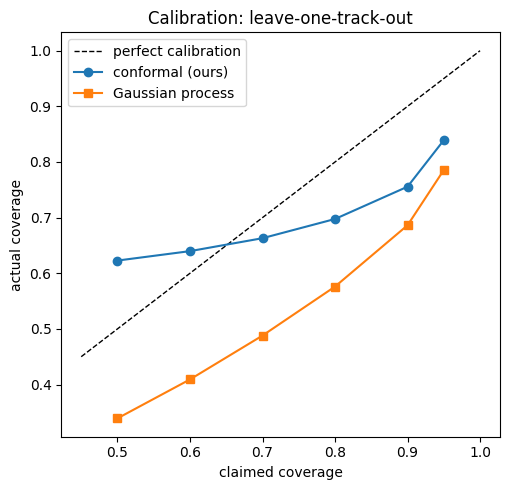

At claimed 90%:  conformal 76%   GP 69%


In [ ]:
from scipy.stats import norm

NOMINALS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
cov_conf = {q: [] for q in NOMINALS}; cov_gp = {q: [] for q in NOMINALS}
d = model_df

for ho in TRACK_IDS:
    tr_tracks = [t for t in TRACK_IDS if t != ho]
    te = d[d.track == ho]
    # conformal: calibrate the residual quantile on each training track in turn (cross-conformal)
    ridge_full = make_pipeline(StandardScaler(), Ridge(1.0)).fit(d[d.track != ho][FEATURES], d[d.track != ho][TARGET])
    err = np.abs(te[TARGET].values - ridge_full.predict(te[FEATURES]))
    resid = []
    for cal in tr_tracks:
        fit = d[d.track.isin([t for t in tr_tracks if t != cal])]
        m = make_pipeline(StandardScaler(), Ridge(1.0)).fit(fit[FEATURES], fit[TARGET])
        c = d[d.track == cal]
        resid.extend(np.abs(c[TARGET].values - m.predict(c[FEATURES])))
    for q in NOMINALS:
        cov_conf[q].append((err <= np.quantile(resid, q)).mean())
    # GP model-based intervals
    sc = StandardScaler().fit(d[d.track != ho][FEATURES])
    gp = GaussianProcessRegressor(DotProduct()+WhiteKernel(), normalize_y=True, random_state=0)
    gp.fit(sc.transform(d[d.track != ho][FEATURES]), d[d.track != ho][TARGET])
    mu, sd = gp.predict(sc.transform(te[FEATURES]), return_std=True)
    gerr = np.abs(te[TARGET].values - mu)
    for q in NOMINALS:
        cov_gp[q].append((gerr <= norm.ppf(0.5 + q/2) * sd).mean())

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0.45, 1], [0.45, 1], 'k--', lw=1, label='perfect calibration')
ax.plot(NOMINALS, [np.mean(cov_conf[q]) for q in NOMINALS], 'o-', label='conformal (ours)')
ax.plot(NOMINALS, [np.mean(cov_gp[q])   for q in NOMINALS], 's-', label='Gaussian process')
ax.set_xlabel('claimed coverage'); ax.set_ylabel('actual coverage'); ax.legend()
ax.set_title('Calibration: leave-one-track-out')
plt.tight_layout(); fig.savefig(OUT_DIR / 'calibration.png', dpi=200, bbox_inches='tight'); plt.show()
print('At claimed 90%%:  conformal %.0f%%   GP %.0f%%' %
      (100*np.mean(cov_conf[0.9]), 100*np.mean(cov_gp[0.9])))

## 7. Anomaly alarm

---

Some failures are sudden drops rather than gradual drift, and those are better flagged than predicted. This alarm flags any slice whose melt area, peak, or pool width deviates more than *k* robust-sigma from a rolling median, meaning its normal local neighborhood. The k value sets how sensitive this alarm is, and we test it against 2 collapse events (Track 8, ≈ 45.9 mm, Track 10, ≈ 77 mm) we already know about.

In [ ]:
MONITORS = ['melt_area', 'peak', 'pool_wid']
def run_alarm(k):
    events_per_track = {}
    for tid in TRACK_IDS:
        t = master[master.track == tid].sort_values('x_mm').reset_index(drop=True)
        flagged = np.zeros(len(t), dtype=bool)
        for f in MONITORS:
            med = t[f].rolling(51, center=True, min_periods=15).median()
            mad = 1.4826 * (t[f] - med).abs().rolling(51, center=True, min_periods=15).median()
            flagged |= ((t[f] - med).abs() / mad.clip(lower=1e-9) > k).values
        xs = t.loc[flagged, 'x_mm'].values
        ev = []
        for x in xs:
            if ev and x - ev[-1][-1] <= 0.4: ev[-1].append(x)
            else: ev.append([x])
        events_per_track[tid] = ev
    return events_per_track

for k in (4.0, 3.0):
    ev = run_alarm(k)
    total = sum(len(v) for v in ev.values())
    hit8  = any(e[0]-1 <= 45.9 <= e[-1]+1 for e in ev[8])
    hit10 = any(e[0]-1 <= 77.0 <= e[-1]+1 for e in ev[10])
    print(f'k={k}:  {total} flags total  |  Track 8 @45.9 detected: {hit8}  |  Track 10 @77 detected: {hit10}  '
          f'|  per-track flags: {[len(ev[t]) for t in TRACK_IDS]}')

k=4.0:  32 flags total  |  Track 8 @45.9 detected: False  |  Track 10 @77 detected: True  |  per-track flags: [7, 3, 10, 12]
k=3.0:  65 flags total  |  Track 8 @45.9 detected: True  |  Track 10 @77 detected: True  |  per-track flags: [11, 13, 18, 23]


## 8. Submission : Track 21 (200 W) geometry prediction

---



This is the final deliverable for submission. It is the predicted width, upper boundary, and lower boundary for track 21, each with a 90% calibrated confidence interval. This was trained on the remaining 3 powers: 300, 350, and 400 W tracks. We compare it against the real height map and save the output to `outputs/submission_track21.csv`.

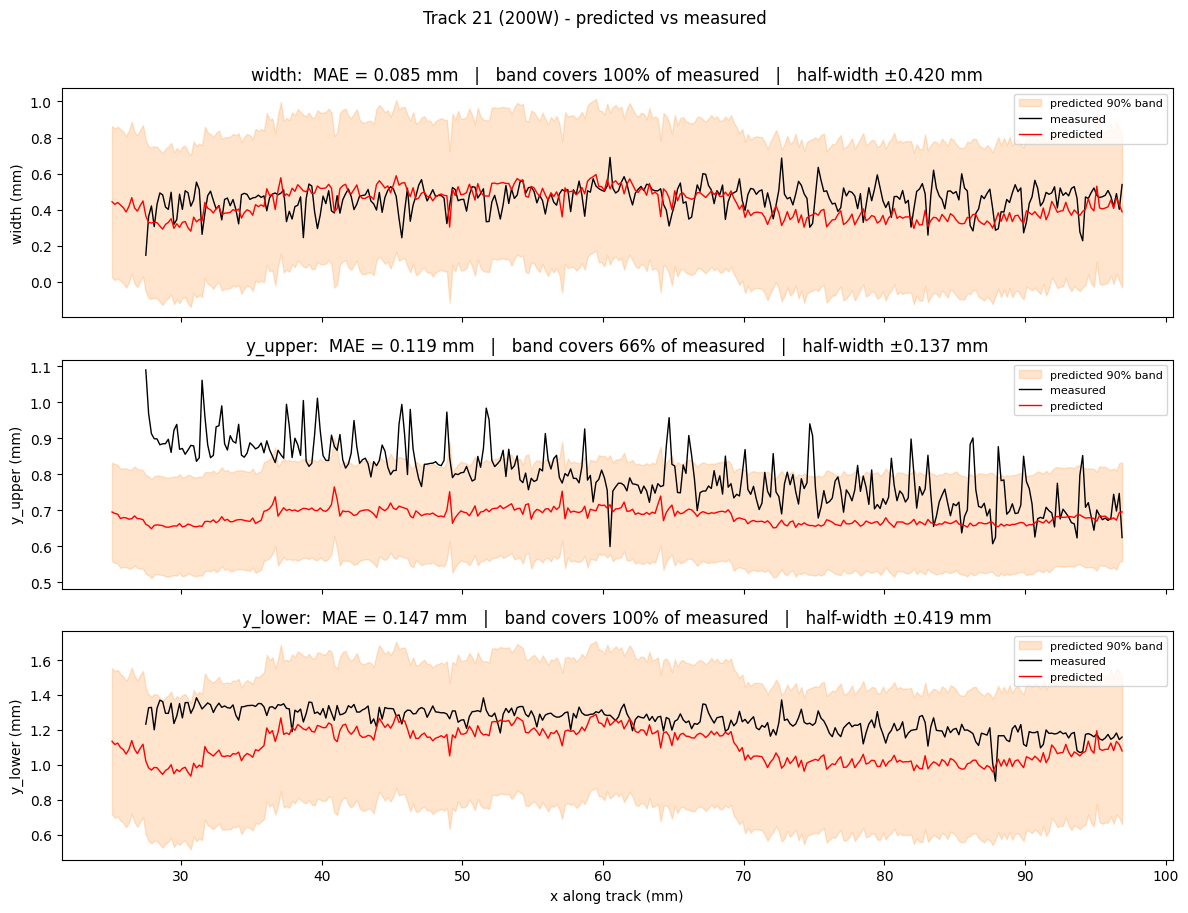

Saved outputs/submission_track21.csv  ( 360 positions )

All outputs in /content/nsf_fmrg/outputs :
   calibration.png
   master.csv
   submission_track21.csv
   submission_track21.png
   table1_model_comparison.csv


In [ ]:
TRAIN = [t for t in TRACK_IDS if t != HELD_OUT_SUBMISSION]
sub_src = master[(master.track == HELD_OUT_SUBMISSION) & (master.quality_flag == 'ok')].dropna(subset=FEATURES).sort_values('x_mm')
out = pd.DataFrame({'x_mm': sub_src['x_mm'].values})

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, tgt in zip(axes, ['width_mean', 'y_upper', 'y_lower']):
    tr = master[master.track.isin(TRAIN) & (master.quality_flag == 'ok')].dropna(subset=FEATURES + [tgt])
    model = make_pipeline(StandardScaler(), Ridge(1.0)).fit(tr[FEATURES], tr[tgt])
    pred = model.predict(sub_src[FEATURES])
    # cross-conformal 90% half-width
    qs = []
    for cal in TRAIN:
        fit = master[master.track.isin([t for t in TRAIN if t != cal])].dropna(subset=FEATURES + [tgt])
        cm = make_pipeline(StandardScaler(), Ridge(1.0)).fit(fit[FEATURES], fit[tgt])
        c = master[(master.track == cal) & (master.quality_flag == 'ok')].dropna(subset=FEATURES + [tgt])
        qs.append(np.quantile(np.abs(c[tgt].values - cm.predict(c[FEATURES])), 0.9))
    q = float(np.mean(qs))
    meas = sub_src[tgt].values
    name = {'width_mean': 'width', 'y_upper': 'y_upper', 'y_lower': 'y_lower'}[tgt]
    out[f'{name}_pred'], out[f'{name}_lo90'], out[f'{name}_hi90'], out[f'{name}_measured'] = pred, pred-q, pred+q, meas
    v = np.isfinite(meas)
    mae = np.mean(np.abs(pred[v] - meas[v])); cov = 100*np.mean(np.abs(pred[v]-meas[v]) <= q)
    ax.fill_between(sub_src['x_mm'], pred-q, pred+q, alpha=0.2, color='tab:orange', label='predicted 90% band')
    ax.plot(sub_src['x_mm'], meas, 'k-', lw=1, label='measured')
    ax.plot(sub_src['x_mm'], pred, 'r-', lw=1, label='predicted')
    ax.set_ylabel(f'{name} (mm)'); ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{name}:  MAE = {mae:.3f} mm   |   band covers {cov:.0f}% of measured   |   half-width ±{q:.3f} mm')
axes[-1].set_xlabel('x along track (mm)')
fig.suptitle(f'Track {HELD_OUT_SUBMISSION} ({POWER_W[HELD_OUT_SUBMISSION]}W) - predicted vs measured', y=1.01)
plt.tight_layout(); fig.savefig(OUT_DIR / 'submission_track21.png', dpi=200, bbox_inches='tight'); plt.show()

out.to_csv(OUT_DIR / 'submission_track21.csv', index=False)
print('Saved outputs/submission_track21.csv  (', out.shape[0], 'positions )')
print('\nAll outputs in', OUT_DIR, ':')
for f in sorted(OUT_DIR.iterdir()):
    print('  ', f.name)

## 9. Presentation Visualizations

---

These are the visuals for the slides, built from the same results as the analysis above.

In [ ]:
# run once before the figure cells — makes every figure save as editable SVG too
plt.rcParams['svg.fonttype'] = 'none'

def save_editable(stem):
    fig = plt.gcf()
    for ext in ('png', 'svg', 'pdf'):
        fig.savefig(f'/content/nsf_fmrg/outputs/{stem}.{ext}',
                    facecolor='#0a0604', bbox_inches='tight')

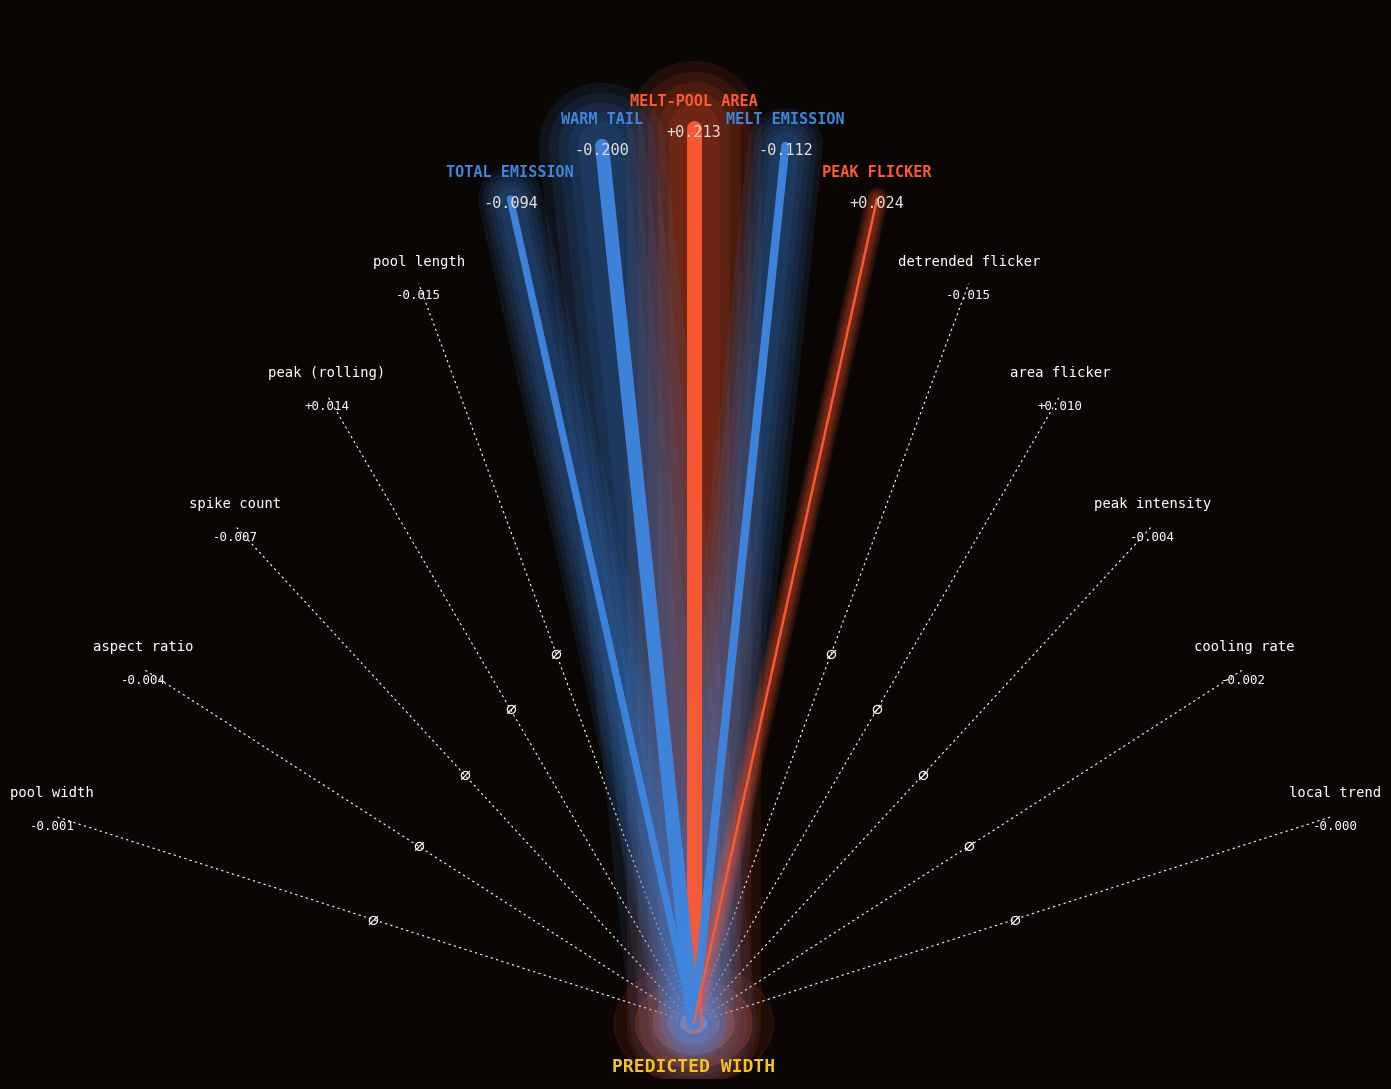

In [ ]:
# The model as optics (Ridge coefficients as beams)
import matplotlib.patheffects as pe
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

F15 = ['melt_area','warm_tail_area','melt_intensity','total_emission','peak_roll_mean',
       'pool_len','peak_roll_std','spike_count','area_roll_std','detrended_roll_std',
       'pool_aspect','trend_slope','peak','cooling_rate','pool_wid']
NAME = {'melt_area':'melt-pool area','warm_tail_area':'warm tail','melt_intensity':'melt emission',
        'total_emission':'total emission','peak_roll_mean':'peak (rolling)','pool_len':'pool length',
        'peak_roll_std':'peak flicker','spike_count':'spike count','area_roll_std':'area flicker',
        'detrended_roll_std':'detrended flicker','pool_aspect':'aspect ratio','trend_slope':'local trend',
        'peak':'peak intensity','cooling_rate':'cooling rate','pool_wid':'pool width'}
SHUTTER = 0.02

d = master[(master.quality_flag=='ok') & master.width_mean.notna()].dropna(subset=F15)
mdl = make_pipeline(StandardScaler(), Ridge(1.0)).fit(d[F15], d['width_mean'])
coef = dict(zip(F15, mdl[-1].coef_))

order = sorted(F15, key=lambda f: abs(coef[f]), reverse=True)
n = len(order)

slots = np.linspace(-0.05, 1.05, n)
slot_order = np.argsort(np.abs(slots-0.5))
place = {order[i]: slots[slot_order[i]] for i in range(n)}
mx = max(abs(c) for c in coef.values())

plt.rcParams.update({'font.family':'monospace'})
fig, ax = plt.subplots(figsize=(14,11)); fig.patch.set_facecolor('#0a0604'); ax.set_facecolor('#0a0604')
ax.set_xlim(-0.1,1.1); ax.set_ylim(0,1.35); ax.axis('off')
fx, fy = 0.5, 0.07
for r,a in [(0.075,0.10),(0.055,0.16),(0.038,0.28),(0.024,0.5)]:
    ax.add_patch(plt.Circle((fx,fy), r, color='#e8542a', alpha=a, transform=ax.transData))
ax.add_patch(plt.Circle((fx,fy), 0.012, color='#fff3e6'))
ax.text(fx, 0.005, 'PREDICTED WIDTH', color='#f5c518', ha='center', va='bottom', fontsize=13, weight='bold')

for f in order:
    t = place[f]; ex = -0.05+1.1*t; ey = 0.45+0.75*np.sin(np.pi*t); c = coef[f]
    col = '#ff5a33' if c>0 else '#3f86e0'
    if abs(c) < SHUTTER:
        ax.plot([fx,ex],[fy,ey], color='#ffffff', lw=0.8, ls=(0,(2,3)), zorder=1)
        mxp=(fx+ex)/2; myp=(fy+ey)/2
        ax.text(mxp,myp,'∅',color='#ffffff',fontsize=13,ha='center',va='center')
        ax.text(ex,ey+0.02,NAME[f],color='#ffffff',ha='center',va='bottom',fontsize=10)
        ax.text(ex,ey-0.005,f'{c:+.3f}',color='#ffffff',ha='center',va='top',fontsize=9)
    else:
        lw = 1.5 + abs(c)/mx*20
        for k in range(5,0,-1):
            ax.plot([fx,ex],[fy,ey], color=col, lw=lw+k*lw*0.7, alpha=0.10, solid_capstyle='round', zorder=2)
        ax.plot([fx,ex],[fy,ey], color=col, lw=lw*0.5, alpha=0.95, solid_capstyle='round', zorder=3)
        ax.text(ex,ey+0.025,NAME[f].upper(),color=col,ha='center',va='bottom',fontsize=11,weight='bold')
        ax.text(ex,ey+0.005,f'{c:+.3f}',color='#e8e0d8',ha='center',va='top',fontsize=11)

# ax.text(0.02,1.16,'THE MODEL AS OPTICS  FIFTEEN BEAMS, ONE PREDICTION',color='#f0e8e0',fontsize=17,weight='bold')
# ax.text(0.02,1.11,'the trained Ridge model, drawn as a beam system converging on the melt pool',color='#8a7d74',fontsize=12)
# ax.text(0.02,0.015,'HOW TO READ : beam thickness = coefficient magnitude , red beams push predicted width UP, '
#         'blue pull it DOWN\nshuttered beams (∅) = features the model learned to IGNORE - every flicker/instability '
#         'beam is sealed: the negative result, inside the model',color='#ffffff',fontsize=10)
plt.tight_layout(); save_editable('fig_optics'); plt.show()

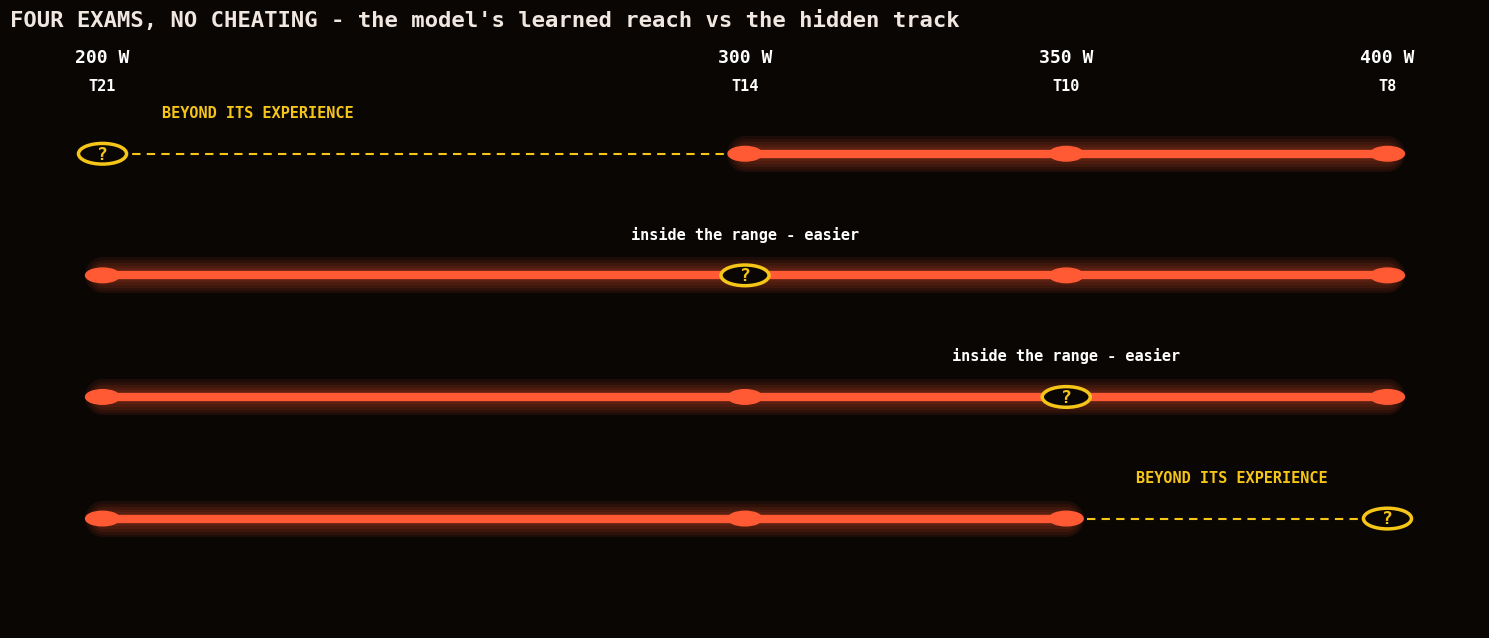

In [ ]:
# Four exams, no cheating (leave-one-track-out)
plt.rcParams.update({'font.family':'monospace'})
fig, ax = plt.subplots(figsize=(15,6.5)); fig.patch.set_facecolor('#0a0604'); ax.set_facecolor('#0a0604'); ax.axis('off')
pmin, pmax = 190, 410
def X(p): return (p-pmin)/(pmax-pmin)
held = [21,14,10,8]                      # row order: 200,300,350,400 held out
for tid, p in sorted(POWER_W.items(), key=lambda kv: kv[1]):
    ax.text(X(p),0.93,f'{p} W',color='#ffffff',ha='center',fontsize=13,weight='bold')
    ax.text(X(p),0.885,f'T{tid}',color='#ffffff',ha='center',fontsize=11,weight='bold')
for i,ho in enumerate(held):
    y = 0.78 - i*0.20
    tr = [POWER_W[t] for t in TRACK_IDS if t!=ho]; lo,hi = min(tr),max(tr); hop = POWER_W[ho]
    for k in range(5,0,-1):
        ax.plot([X(lo),X(hi)],[y,y],color='#ff5a33',lw=6+k*4,alpha=0.08,solid_capstyle='round')
    ax.plot([X(lo),X(hi)],[y,y],color='#ff5a33',lw=6,solid_capstyle='round')
    for p in tr: ax.add_patch(plt.Circle((X(p),y),0.012,color='#ff5a33',zorder=5))
    outside = hop<lo or hop>hi
    if outside:
        ax.plot([X(hop),X(lo if hop<lo else hi)],[y,y],color='#f5c518',lw=1.5,ls=(0,(4,3)),zorder=3)
        ax.text(X(hop)+ (0.11 if hop<lo else -0.11),y+0.06,'BEYOND ITS EXPERIENCE',color='#f5c518',fontsize=11,ha='center',weight='bold')
    else:
        ax.text(X(hop),y+0.06,'inside the range - easier',color='#ffffff',fontsize=11,ha='center',weight='bold')
    ax.add_patch(plt.Circle((X(hop),y),0.017,facecolor='#0a0604',edgecolor='#f5c518',lw=2.5,zorder=6))
    ax.text(X(hop),y,'?',color='#f5c518',ha='center',va='center',fontsize=13,weight='bold',zorder=7)
ax.set_xlim(-0.02,1.02); ax.set_ylim(0,1)
ax.text(0.0,0.99,"FOUR EXAMS, NO CHEATING - the model's learned reach vs the hidden track",
        color='#f0e8e0',fontsize=16,weight='bold',transform=ax.transAxes)
# ax.text(0.0,-0.02,'HOW TO READ : each row = one leave-one-track-out exam , glowing bar = the power range trained on '
#         'gold ? = the track it predicts blind\nwhen ? sits OUTSIDE the bar, the model must extrapolate - the exams where '
#         'flexible models collapsed and Ridge did not',color='#7a6d64',fontsize=10,transform=ax.transAxes)
plt.tight_layout(); save_editable('fig_exams'); plt.show()

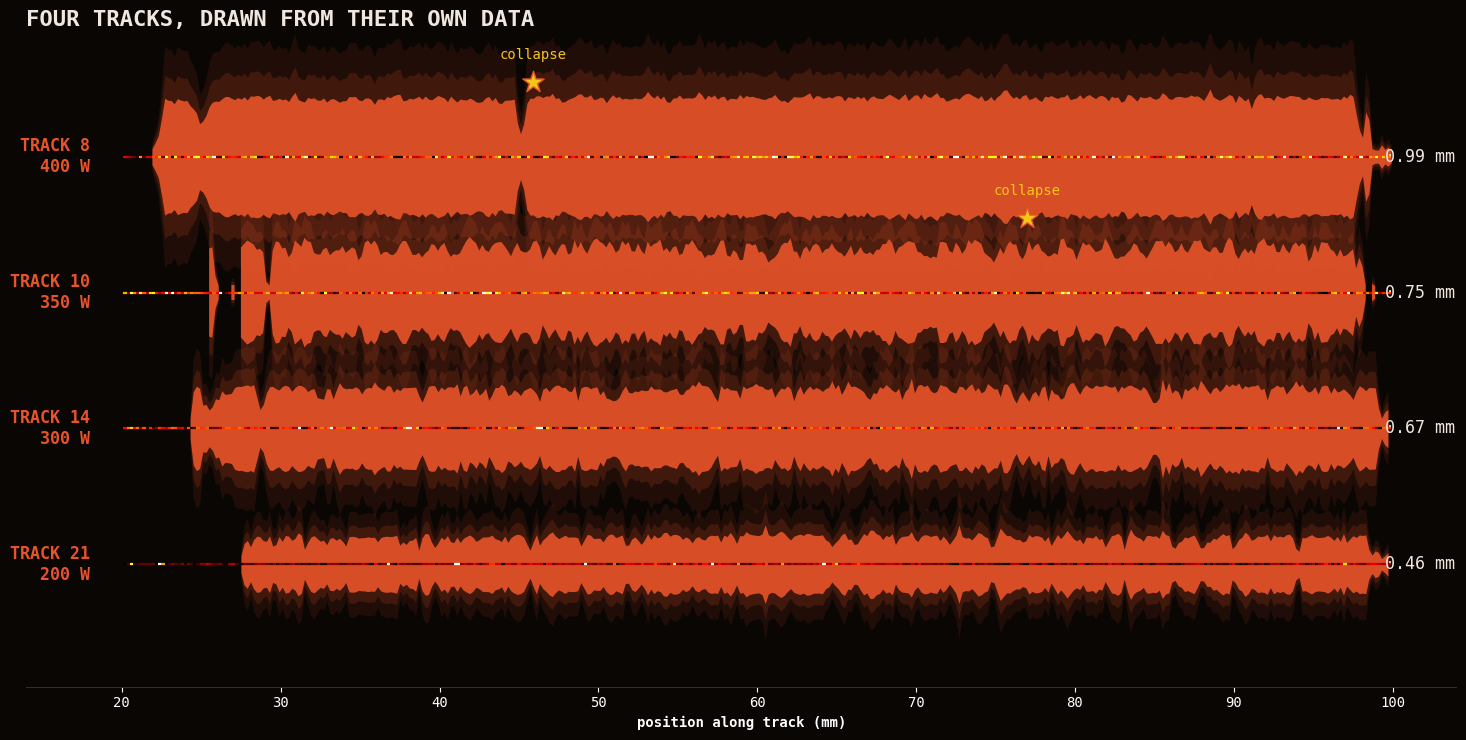

In [ ]:
# 3 our tracks, drawn from their own data
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
plt.rcParams.update({'font.family':'monospace'})
fig, ax = plt.subplots(figsize=(15,7.5)); fig.patch.set_facecolor('#0a0604'); ax.set_facecolor('#0a0604')
collapses = {8:45.9, 10:77.0}
for i,tid in enumerate(TRACK_IDS):
    t = master[master.track==tid].sort_values('x_mm')
    x = t.x_mm.values; w = t.width_mean.values; pk = t.peak.values
    y0 = 3-i; ok = np.isfinite(w)
    half = np.where(ok, w, np.nan)*0.42
    for a,mult in [(0.10,1.9),(0.16,1.4),(0.9,1.0)]:
        ax.fill_between(x, y0-half*mult, y0+half*mult, color='#e8542a', alpha=a, lw=0)
    seg = np.concatenate([np.array([x,np.full_like(x,y0)]).T.reshape(-1,1,2)[:-1],
                          np.array([x,np.full_like(x,y0)]).T.reshape(-1,1,2)[1:]],axis=1)
    lc = LineCollection(seg, cmap='hot', norm=Normalize(np.nanpercentile(pk,5),np.nanpercentile(pk,99)))
    lc.set_array(pk[:-1]); lc.set_linewidth(1.6); ax.add_collection(lc)
    ax.text(18, y0, f'TRACK {tid}\n{POWER_W[tid]} W', color='#e8542a', ha='right', va='center', fontsize=12, weight='bold')
    ax.text(99.5, y0, f'{np.nanmean(w):.2f} mm', color='#f0e8e0', ha='left', va='center', fontsize=12)
    if tid in collapses:
        cx = collapses[tid]; ax.scatter([cx],[y0+0.55],marker='*',s=260,color='#f5c518',zorder=6,edgecolor='#e8542a')
        ax.text(cx,y0+0.72,'collapse',color='#f5c518',ha='center',fontsize=10)
ax.set_xlim(14,104); ax.set_ylim(-0.9,3.9); ax.set_yticks([])
for s in ['top','right','left']: ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color('#3a2a22'); ax.tick_params(colors='#ffffff')
ax.set_xlabel('position along track (mm)', color='#ffffff', weight='bold')
ax.set_title('FOUR TRACKS, DRAWN FROM THEIR OWN DATA', color='#f0e8e0', fontsize=16, weight='bold', loc='left')
# ax.text(0.0,1.02,'bead thickness = measured width , glow = thermal intensity  ★ = alarm-flagged collapse',
#         color='#8a7d74',fontsize=11,transform=ax.transAxes)
plt.tight_layout(); save_editable('fig_tracks'); plt.show()

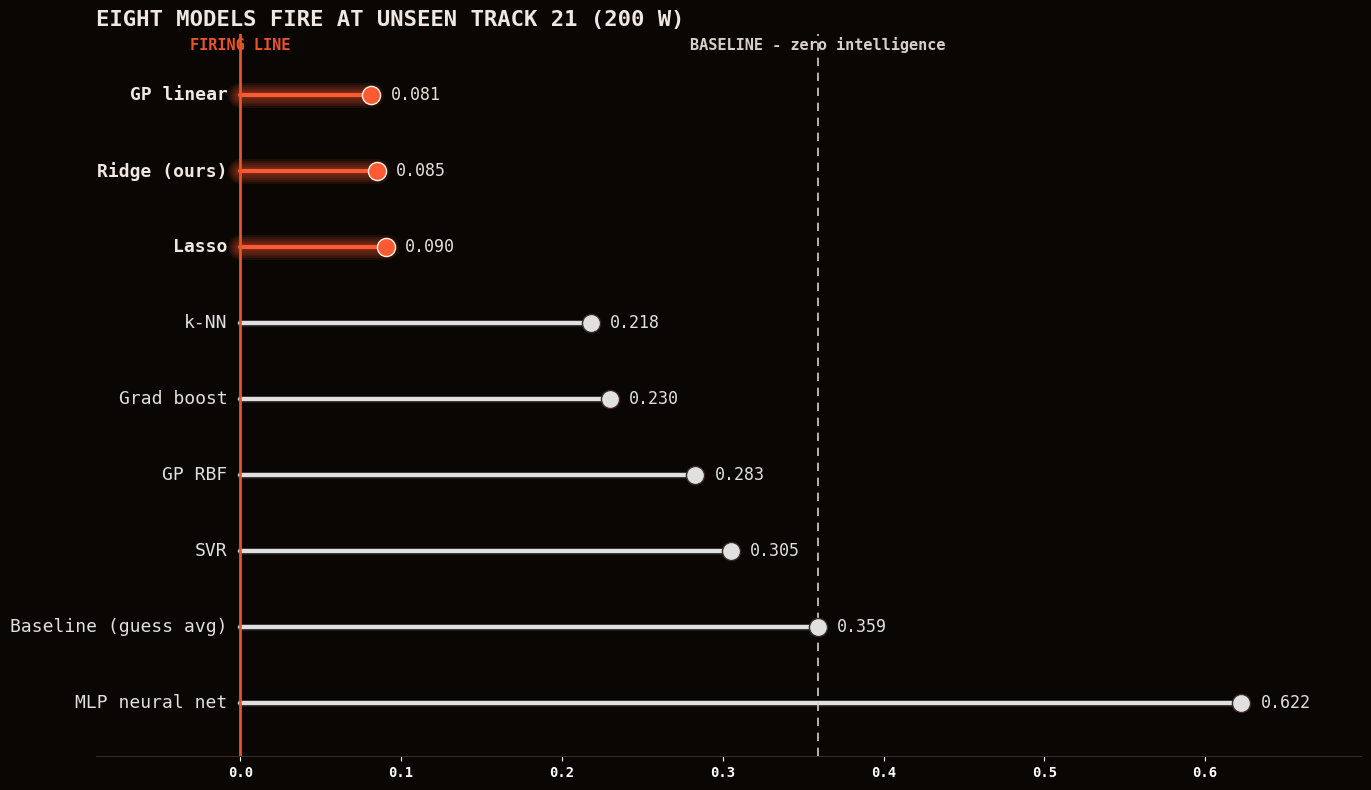

In [ ]:
# 4 Eight models fire at unseen Track 21
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, RBF, WhiteKernel
from sklearn.metrics import mean_absolute_error

Fm = ['peak','melt_area','total_emission','pool_len','pool_wid','pool_aspect',
      'cooling_rate','peak_roll_mean','peak_roll_std','area_roll_std']
dm = master[(master.quality_flag=='ok') & master.width_mean.notna()].dropna(subset=Fm)
tr, te = dm[dm.track!=21], dm[dm.track==21]
zoo = {'Lasso':make_pipeline(StandardScaler(),Lasso(0.001,max_iter=5000)),
       'Ridge (ours)':make_pipeline(StandardScaler(),Ridge(1.0)),
       'GP linear':make_pipeline(StandardScaler(),GaussianProcessRegressor(DotProduct()+WhiteKernel(),normalize_y=True,random_state=0)),
       'k-NN':make_pipeline(StandardScaler(),KNeighborsRegressor(25)),
       'Grad boost':HistGradientBoostingRegressor(max_depth=4,learning_rate=0.06,max_iter=300,random_state=0),
       'SVR':make_pipeline(StandardScaler(),SVR(C=1.0)),
       'GP RBF':make_pipeline(StandardScaler(),GaussianProcessRegressor(1.0*RBF()+WhiteKernel(),normalize_y=True,random_state=0)),
       'MLP neural net':make_pipeline(StandardScaler(),MLPRegressor((32,16),max_iter=2000,random_state=0))}
mae = {n:mean_absolute_error(te['width_mean'], m.fit(tr[Fm],tr['width_mean']).predict(te[Fm])) for n,m in zoo.items()}
mae['Baseline (guess avg)'] = mean_absolute_error(te['width_mean'], np.full(len(te), tr['width_mean'].mean()))
LIN = {'Lasso','Ridge (ours)','GP linear'}
items = sorted(mae.items(), key=lambda kv: kv[1]); base = mae['Baseline (guess avg)']

plt.rcParams.update({'font.family':'monospace'})
fig, ax = plt.subplots(figsize=(14,8)); fig.patch.set_facecolor('#0a0604'); ax.set_facecolor('#0a0604')
for i,(name,v) in enumerate(items):
    y = len(items)-1-i; lin = name in LIN; col = '#ff5a33' if lin else '#e0e0e0'
    for k in ([5,4,3,2,1] if lin else [2,1]):
        ax.plot([0,v],[y,y],color=col,lw=3+k*(3 if lin else 1),alpha=0.10,solid_capstyle='round')
    ax.plot([0,v],[y,y],color=col,lw=3,solid_capstyle='round')
    ax.scatter([v],[y],s=170,color=col,edgecolor='#fff3e6' if lin else '#3a2a22',zorder=5)
    ax.text(-0.008,y,name,color='#f0e8e0' if lin else '#e0e0e0',ha='right',va='center',
            fontsize=13,weight='bold' if lin else 'normal')
    ax.text(v+0.012,y,f'{v:.3f}',color='#e8e0d8' if lin else '#e0e0e0',va='center',fontsize=12)
ax.axvline(0,color='#e8542a',lw=2,zorder=4); ax.text(0,len(items)-0.4,'FIRING LINE',color='#e8542a',fontsize=11,ha='center',weight='bold',zorder=6)
ax.axvline(base,color='#d8d0c8',lw=1.2,ls=(0,(5,4)),zorder=4)
ax.text(base,len(items)-0.4,'BASELINE - zero intelligence',color='#d8d0c8',fontsize=11,ha='center',weight='bold',zorder=6)
ax.set_xlim(-0.09,max(mae.values())*1.12); ax.set_ylim(-0.7,len(items)-0.2); ax.set_yticks([])
for s in ['top','right','left']: ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color('#3a2a22'); ax.tick_params(colors='#ffffff', labelsize=10)
for tick in ax.get_xticklabels():
    tick.set_weight('bold')
ax.set_title('EIGHT MODELS FIRE AT UNSEEN TRACK 21 (200 W)',color='#f0e8e0',fontsize=16,weight='bold',loc='left')
# ax.text(0.0,-0.11,'(HOW TO READ) beam length = average error (mm) on the never-seen track - shorter is better ; '
#         'bright = linear models\nevery linear model stops short; nonlinear models fly past - the neural net past even the '
#         'guessing line',color='#7a6d64',fontsize=10,transform=ax.transAxes)
plt.tight_layout(); save_editable('fig_firing'); plt.show()

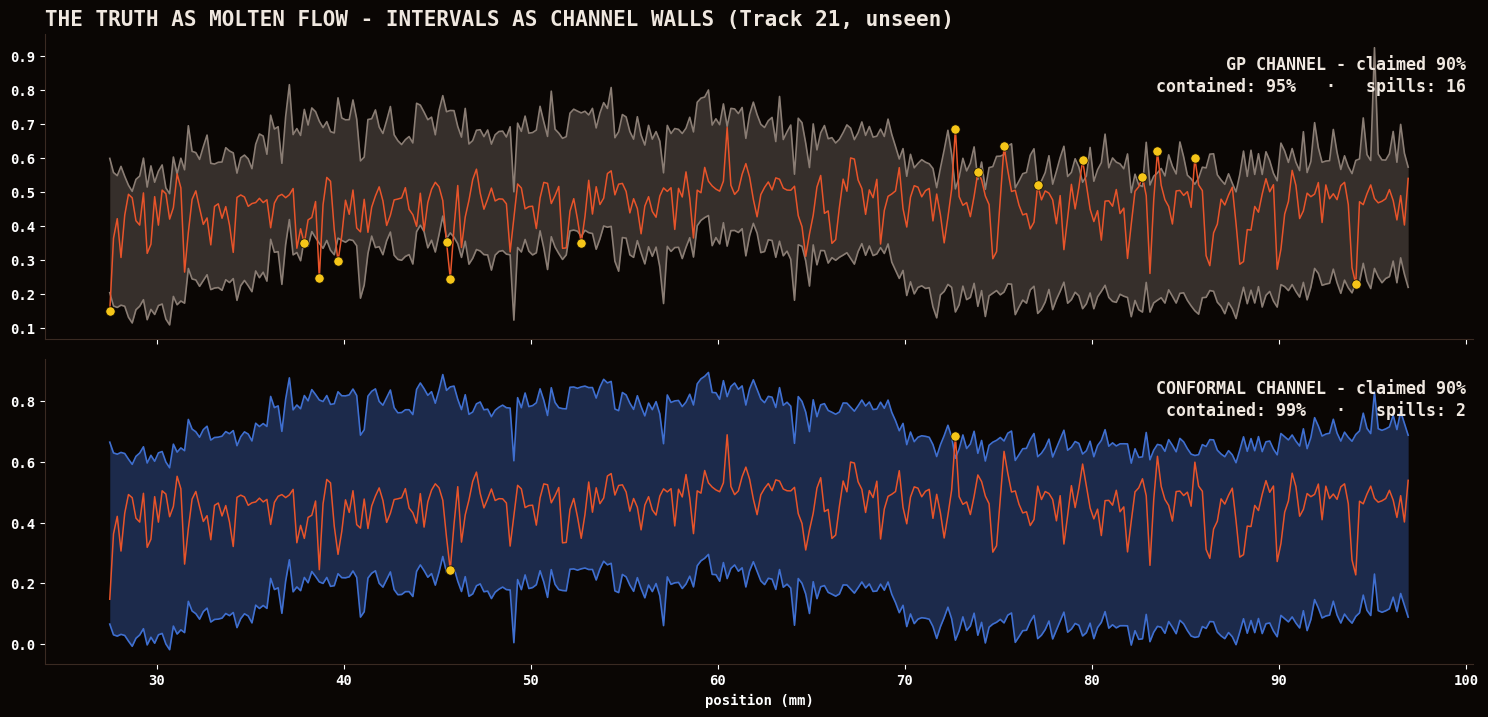

In [ ]:
# The truth as molten flow (GP vs conformal channels, Track 21)
from scipy.stats import norm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel

Fm = ['peak','melt_area','total_emission','pool_len','pool_wid','pool_aspect',
      'cooling_rate','peak_roll_mean','peak_roll_std','area_roll_std']
dm = master[(master.quality_flag=='ok') & master.width_mean.notna()].dropna(subset=Fm)
tr = dm[dm.track!=21]; te = dm[dm.track==21].sort_values('x_mm')
x, meas = te.x_mm.values, te['width_mean'].values
# conformal q (cross-conformal on training tracks)
q=[]
for cal in [8,10,14]:
    fit = dm[dm.track.isin([t for t in [8,10,14] if t!=cal])]
    cm = make_pipeline(StandardScaler(),Ridge(1.0)).fit(fit[Fm],fit['width_mean']); c=dm[dm.track==cal]
    q.append(np.quantile(np.abs(c['width_mean'].values-cm.predict(c[Fm])),0.9))
q=float(np.mean(q))
ridge = make_pipeline(StandardScaler(),Ridge(1.0)).fit(tr[Fm],tr['width_mean']); pr = ridge.predict(te[Fm])
sc = StandardScaler().fit(tr[Fm]); gp = GaussianProcessRegressor(DotProduct()+WhiteKernel(),normalize_y=True,random_state=0)
gp.fit(sc.transform(tr[Fm]),tr['width_mean']); mu,sd = gp.predict(sc.transform(te[Fm]),return_std=True); g=1.645*sd

plt.rcParams.update({'font.family':'monospace'})
fig, axes = plt.subplots(2,1,figsize=(15,7.5),sharex=True); fig.patch.set_facecolor('#0a0604')
panels = [(axes[0],mu,g,'#8a7d74','GP CHANNEL'),(axes[1],pr,np.full_like(pr,q),'#3f6fd0','CONFORMAL CHANNEL')]
for ax,pred,band,col,name in panels:
    ax.set_facecolor('#0a0604')
    ax.fill_between(x,pred-band,pred+band,color=col,alpha=0.35,lw=0)
    ax.plot(x,pred+band,color=col,lw=1.2); ax.plot(x,pred-band,color=col,lw=1.2)
    ax.plot(x,meas,color='#e8542a',lw=1.1)
    spill = np.abs(meas-pred)>band
    ax.scatter(x[spill],meas[spill],s=45,color='#f5c518',zorder=5,edgecolor='#0a0604',lw=0.5)
    cov = 100*np.mean(~spill)
    ax.text(0.995,0.93,f'{name} - claimed 90%\ncontained: {cov:.0f}%   ·   spills: {int(spill.sum())}',
            color='#f0e8e0',ha='right',va='top',transform=ax.transAxes,fontsize=12,weight='bold')
    for s in ['top','right']: ax.spines[s].set_visible(False)
    for s in ['bottom','left']: ax.spines[s].set_color('#3a2a22')
    ax.tick_params(colors='#ffffff', labelsize=10)
    for tick in ax.get_yticklabels():
        tick.set_weight('bold')
axes[1].set_xlabel('position (mm)',color='#ffffff',weight='bold')
axes[1].tick_params(colors='#ffffff', labelsize=10)
for tick in axes[1].get_xticklabels():
    tick.set_weight('bold')
axes[0].set_title('THE TRUTH AS MOLTEN FLOW - INTERVALS AS CHANNEL WALLS (Track 21, unseen)',
                  color='#f0e8e0',fontsize=15,weight='bold',loc='left')
# fig.text(0.13,0.02,'HOW TO READ : red stream = measured width ; shaded = the interval each method promised would contain '
#          '90% of it ; gold droplets = SPILLS (truth escaping the walls)',color='#7a6d64',fontsize=10)
plt.tight_layout(rect=[0,0.03,1,1]); save_editable('fig_channels'); plt.show()

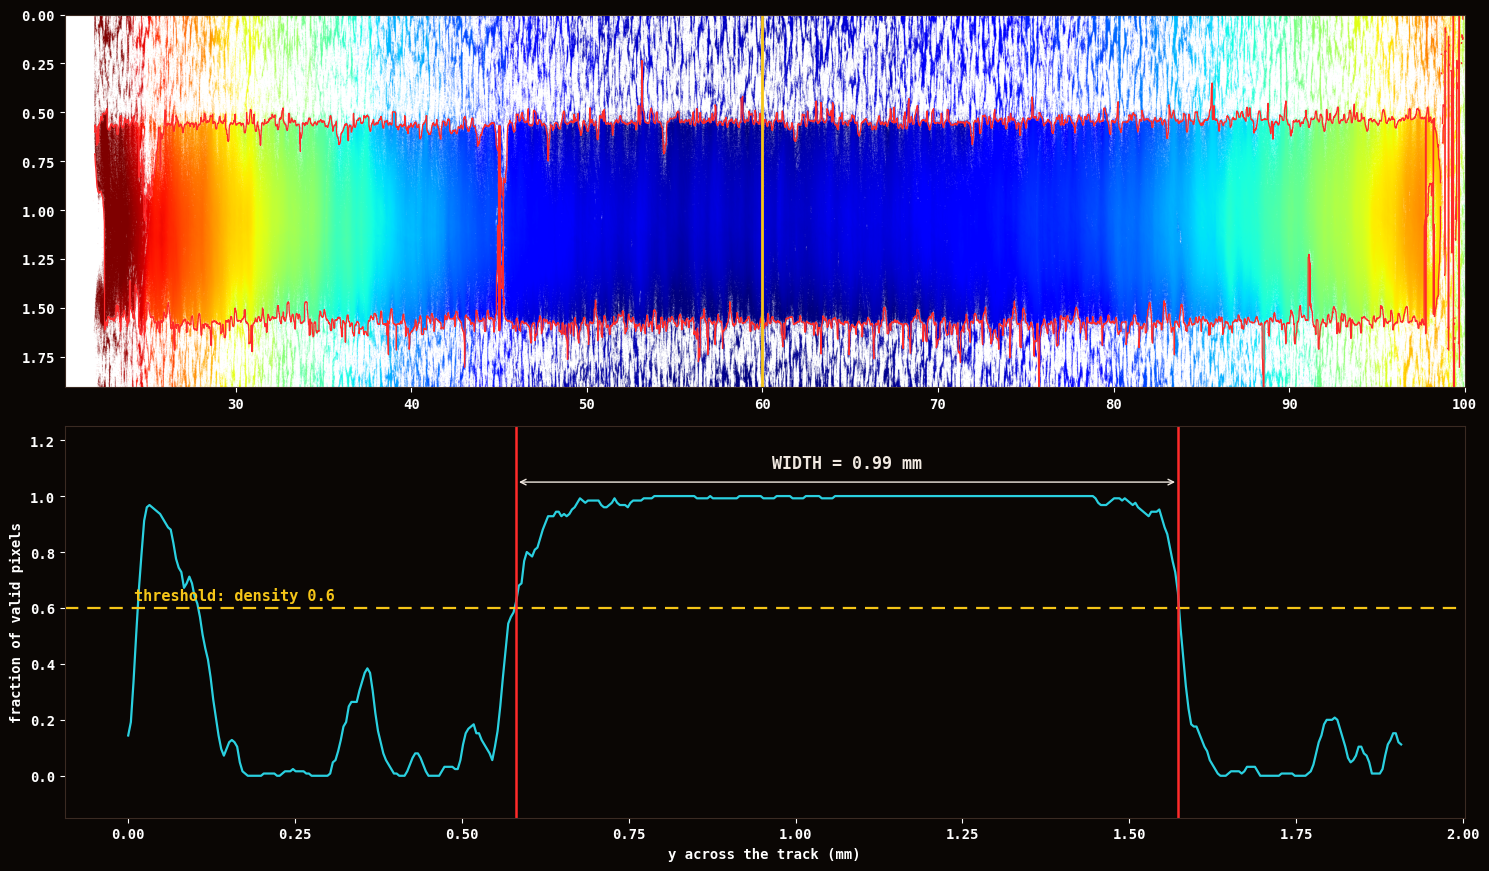

In [ ]:
# 6 How the red boundary is found (Track 8)
plt.rcParams.update({'font.family':'monospace'})
tid, x0mm = 8, 60.0
data = load_wyko_asc(tid, crop_to_common=True); x,y = data['x_actual_mm'], data['y_mm']
Zd,_ = robust_plane_detrend(data['Z_mm'], x, y); Zum = Zd*1000
dens = ndimage.uniform_filter(np.isfinite(data['Z_mm']).astype(np.float32), size=(5,25))
yu = np.full(len(x),np.nan); yl = np.full(len(x),np.nan)
for j in range(len(x)):
    s,e = largest_true_run(dens[:,j]>=0.6)
    if s is not None and (e-s)>=25: yu[j],yl[j]=y[s],y[e-1]
j0 = int(np.argmin(np.abs(x-x0mm)))

fig, (a1,a2) = plt.subplots(2,1,figsize=(15,9),gridspec_kw={'height_ratios':[1,1.05]})
fig.patch.set_facecolor('#0a0604')
cmap = plt.get_cmap('jet').copy(); cmap.set_bad('white')
a1.imshow(np.ma.masked_invalid(Zum), cmap=cmap, aspect='auto', vmin=-50, vmax=125,
          extent=[x[0],x[-1],y[-1],y[0]])
a1.plot(x,yu,color='#ff2a2a',lw=0.9); a1.plot(x,yl,color='#ff2a2a',lw=0.9)
a1.axvline(x[j0],color='#f5c518',lw=2)
# a1.set_title(f'HOW THE RED BOUNDARY IS FOUND - Track {tid}, the real map',color='#f0e8e0',fontsize=15,weight='bold',loc='left')
# a1.text(x[j0],y[0]-0.05,'STEP 1 - pick one position, look down this line',color='#f5c518',fontsize=11,ha='center')
a1.tick_params(colors='#ffffff', labelsize=10)
for tick in a1.get_xticklabels() + a1.get_yticklabels():
    tick.set_weight('bold')
for s in a1.spines.values(): s.set_color('#3a2a22')

a2.set_facecolor('#0a0604')
a2.plot(y, dens[:,j0], color='#2ad0e0', lw=1.6)
a2.axhline(0.6, color='#f5c518', ls=(0,(6,4)), lw=1.6)
a2.text(y[2],0.63,'threshold: density 0.6',color='#f5c518',fontsize=11,weight='bold')
if np.isfinite(yu[j0]):
    a2.axvline(yu[j0],color='#ff2a2a',lw=1.8); a2.axvline(yl[j0],color='#ff2a2a',lw=1.8)
    a2.annotate('', xy=(yl[j0],1.05),xytext=(yu[j0],1.05),arrowprops=dict(arrowstyle='<->',color='#f0e8e0'))
    a2.text((yu[j0]+yl[j0])/2,1.10,f'WIDTH = {yl[j0]-yu[j0]:.2f} mm',color='#f0e8e0',ha='center',fontsize=12,weight='bold')
a2.set_ylim(-0.15,1.25); a2.set_xlabel('y across the track (mm)',color='#ffffff',weight='bold'); a2.set_ylabel('fraction of valid pixels',color='#ffffff',weight='bold')
# a2.set_title('STEP 2 - down that line, count what fraction of pixels are valid',color='#f0e8e0',fontsize=12,loc='left')
a2.tick_params(colors='#ffffff', labelsize=10)
for tick in a2.get_xticklabels() + a2.get_yticklabels():
    tick.set_weight('bold')
for s in a2.spines.values(): s.set_color('#3a2a22')
# fig.text(0.09,0.01,'HOW TO READ : the valid-pixel fraction jumps HIGH on the smooth track, LOW on the rough plate ; '
#          'where it crosses 0.6 = the red edges ; gap between them = the width ; repeated at all 400 positions',
#          color='#7a6d64',fontsize=10)
plt.tight_layout(rect=[0,0.02,1,1]); plt.savefig('/content/nsf_fmrg/outputs/fig_boundary.png',dpi=200,facecolor='#0a0604'); plt.show()

In [ ]:
# 10. Export all figures (PNG + editable SVG) for Canva
import shutil
from google.colab import files
shutil.make_archive('/content/figures', 'zip', '/content/nsf_fmrg/outputs')
files.download('/content/figures.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- Slide 14 calibration numbers ---
print('At claimed 90%:')
print(f'  Conformal (mean):  {100*np.mean(cov_conf[0.9]):.0f}%')
print(f'  GP (mean):         {100*np.mean(cov_gp[0.9]):.0f}%')
print('  Per-track GP coverage:')
for i, ho in enumerate(TRACK_IDS):
    print(f'    Track {ho}: {100*cov_gp[0.9][i]:.0f}%')

At claimed 90%:
  Conformal (mean):  76%
  GP (mean):         69%
  Per-track GP coverage:
    Track 8: 24%
    Track 10: 63%
    Track 14: 92%
    Track 21: 95%
